In [8]:
import pandas as pd
import ollama

In [9]:
df = pd.read_parquet(rf"E:\Data\query-earth\git-10mil\git_10m_1000000_random.parquet")

In [10]:
df

,img_name,img_quality_score,caption,caption_length,resolution,longitude,latitude,image_bytes
0,Google-18-18_134332_86661.jpg,4.746423,The satellite image shows an urban residential...,72,0.5m/pix,4.476929,51.940032,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
1,Google-18-18_214082_114009.jpg,4.554353,This satellite image shows a golf course. On t...,47,0.5m/pix,113.996887,22.805301,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
2,Google-15-15_10589_11823.jpg,4.730506,The satellite image depicts a coastal area wit...,49,4m/pix,-63.665771,44.723320,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
3,Google-13-13_6796_2552.jpg,4.455812,The satellite image shows a predominantly natu...,59,16m/pix,118.652344,55.973798,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
4,Google-18-18_126400_84963.jpg,4.186256,The satellite image shows a small roundabout a...,54,0.5m/pix,-6.416016,53.354650,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
...,...,...,...,...,...,...,...,...
649995,Google-18-18_140710_86072.jpg,4.475109,The satellite image shows a railway line runni...,60,0.5m/pix,13.235779,52.435921,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
649996,Google-17-17_99472_52428.jpg,3.852470,The satellite image shows a mostly green and b...,48,1m/pix,93.208008,33.843045,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
649997,Google-18-18_146334_27516.jpg,4.398231,The satellite image shows a commercial or indu...,60,0.5m/pix,20.959167,80.445842,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
649998,Google-17-17_93661_53490.jpg,4.654341,The satellite image shows a rural area with sc...,57,1m/pix,77.247620,31.386468,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


In [41]:
from ollama import chat

row = 10
# 1. Extract the raw image bytes from your DataFrame
# Replace 'row_index' with your actual row label/index and 'column_name' with your image column
image_bytes = df.at[row, 'image_bytes']


In [42]:
from PIL import Image 
import io

# 2. Convert bytes to an active PIL Image and display it
image = Image.open(io.BytesIO(image_bytes))
image.show()

In [43]:
# 2. Pass the bytes directly into the chat function
response = chat(
    model='ministral-3:3b', 
    messages=[{
        'role': 'user',
        'content': "List all the thing you see like labels in this image, like 'red buildings', 'car', 'tree'. Return just comma separated list and nothiing else",
        'images': [image_bytes] # Ollama accepts raw bytes directly inside the list
    }],
)

keywords = response.message.content

print("Caption: ", df.at[row, 'caption'])
print("Keywords: ", keywords)

Caption:  The satellite image shows a residential neighborhood with rows of houses, parked cars, and narrow streets forming a grid-like pattern. Vegetation is present in small garden areas adjacent to the houses. The layout includes intersections with small grassy medians.
Keywords:  Residential houses, paved roads, parked cars, street signs, utility poles, small open spaces/gardens, rooftop solar panels, streetlights, parked bicycles, pedestrian pathways, drainage ditches, parked motorcycles, parked minivans, street-level shops, visible windows, parked vans, parked trucks, road markings, parked cars in different orientations.


In [54]:
# 2. Pass the bytes directly into the chat function
response = chat(
    model='ministral-3:3b', 
    messages=[{
        'role': 'user',
        'content': "Generate a 1-2 sentence caption for this image. Nothing else. Try to describe the scene.",
        'images': [image_bytes] # Ollama accepts raw bytes directly inside the list
    }],
)

print("Caption: ", df.at[row, 'caption'])
print("Generated", response.message.content)

Caption:  The satellite image shows an industrial area with several buildings, vehicles, and equipment. There is a large rectangular building with a white roof on the left and another long rectangular building with a darker roof in the center. Various vehicles, including trucks and cars, are parked around the area. There are also numerous pieces of equipment and materials scattered throughout the site. A road runs along the top of the image, adjacent to the industrial area.
Generated An aerial view of a busy construction or logistics site with heavy machinery, stacked materials, and parked vehicles arranged around a large open area.


In [22]:
import io
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image


def run_sam3_on_parquet_row(df: pd.DataFrame, row_index = 10, prompt="trees"):
    # Determine the device and autocast dtype
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1. Load SAM 3 Model & Processor
    print("Loading SAM 3 model...")
    model = build_sam3_image_model()
    model.to(device)
    processor = Sam3Processor(model)

    # 2. Extract image from DataFrame
    img_bytes = df.iloc[row_index]["image_bytes"]
    meta = df.iloc[row_index]
    image = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # 3. Perform SAM 3 Inference with Autocast
    print(f"Running SAM 3 with prompt: '{prompt}'...")
    start_time = time.perf_counter()

    # Use autocast to handle Float vs BFloat16 matrix operations smoothly
    with torch.cuda.amp.autocast(dtype=torch.bfloat16 if device == "cuda" else torch.float32):
        inference_state = processor.set_image(image)
        output = processor.set_text_prompt(state=inference_state, prompt=prompt)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed_time = time.perf_counter() - start_time
    print(f"Inference Completed in: {elapsed_time * 1000:.2f} ms ({elapsed_time:.3f} s)")

    # 4. Extract Output Mask
    masks = output["masks"]
    if len(masks) == 0:
        print("No objects detected for the prompt.")
        combined_mask = np.zeros((image.height, image.width), dtype=bool)
    else:
        masks_np = masks.detach().cpu().numpy() if isinstance(masks, torch.Tensor) else np.array(masks)
        masks_np = np.squeeze(masks_np)
        combined_mask = (masks_np > 0.5) if masks_np.ndim == 2 else np.any(masks_np > 0.5, axis=0)

    # 5. Overlay Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(image)
    ax[0].set_title(f"Tile: {meta.get('file_name', row_index)}")
    ax[0].axis("off")

    ax[1].imshow(image)
    overlay = np.zeros((*np.array(image).shape[:2], 4), dtype=np.float32)
    overlay[combined_mask] = [0.0, 1.0, 0.0, 0.45]  # Green with opacity
    ax[1].imshow(overlay)
    ax[1].set_title(f"Prompt: '{prompt}' ({elapsed_time * 1000:.1f} ms)")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

Loading SAM 3 model...
Running SAM 3 with prompt: 'trees'...


C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\625921938.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16 if device == "cuda" else torch.float32):


Inference Completed in: 963.24 ms (0.963 s)


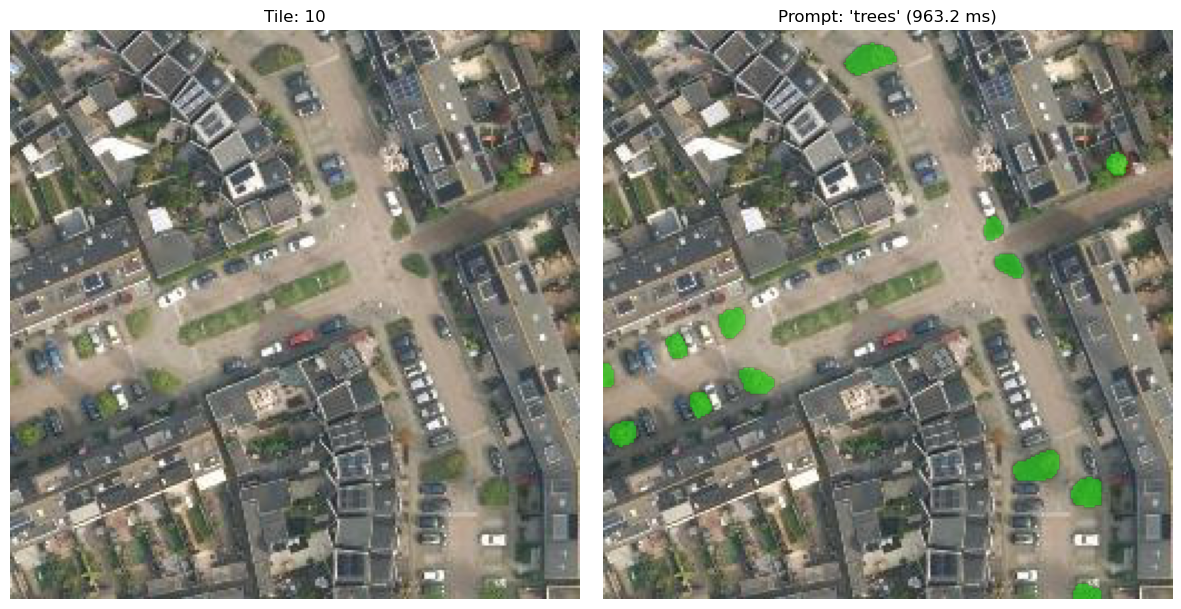

In [23]:
run_sam3_on_parquet_row(df)

Loading SAM 3 model...
Running SAM 3 with prompt: 'cars'...


C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\625921938.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16 if device == "cuda" else torch.float32):


Inference Completed in: 232.10 ms (0.232 s)


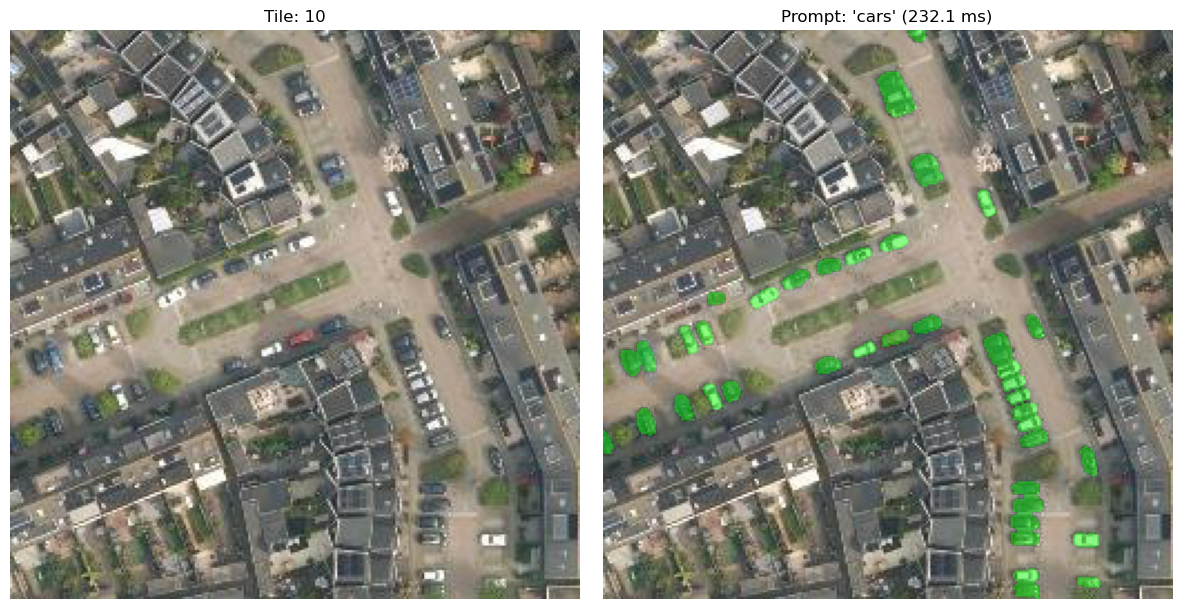

In [24]:
run_sam3_on_parquet_row(df, prompt="cars")

Loading SAM 3 model...
Running SAM 3 with prompt: 'solar panels'...


C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\625921938.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16 if device == "cuda" else torch.float32):


Inference Completed in: 224.04 ms (0.224 s)


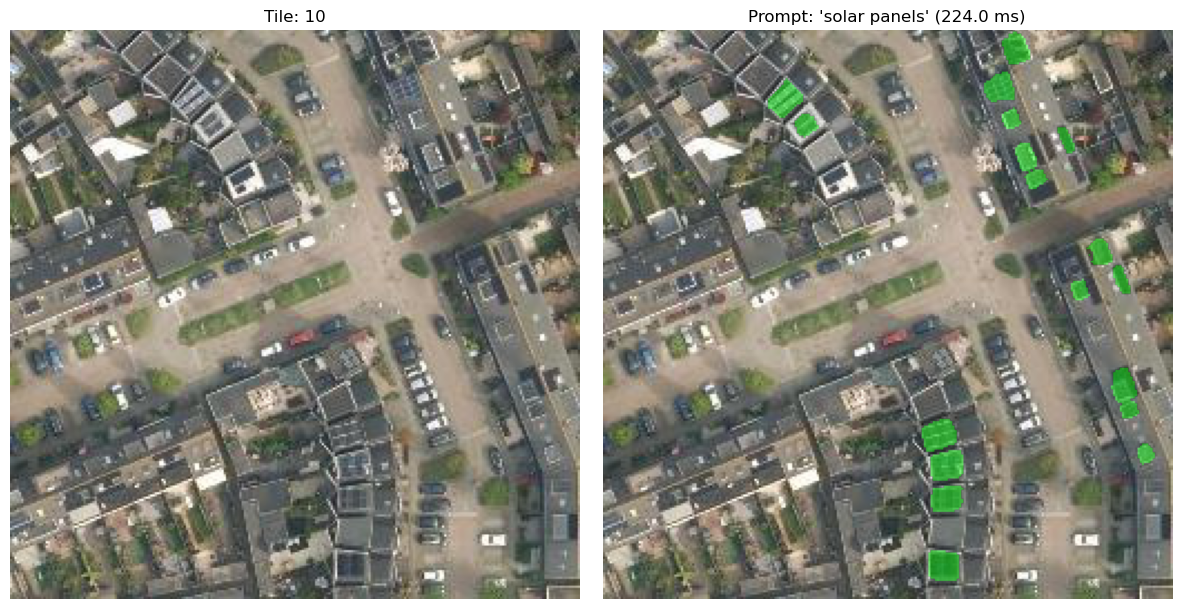

In [25]:
run_sam3_on_parquet_row(df, prompt="solar panels")

Loading SAM 3 model on cuda...
Extracting keywords via Ollama (ministral-3:3b)...
Caption:  The satellite image shows a residential neighborhood with rows of houses, parked cars, and narrow streets forming a grid-like pattern. Vegetation is present in small garden areas adjacent to the houses. The layout includes intersections with small grassy medians.
Keywords (3048.1 ms): ['Roofs with varied textures', 'residential houses', 'multi-story buildings', 'parked cars', 'moving vehicles', 'road signs', 'streetlights', 'traffic cones', 'utility poles', 'electrical wires', 'small patches of grass', 'trees', 'driveways', 'sidewalks', 'parked bicycles', 'mailboxes', 'trash cans', 'street signs', 'fire hydrants', 'road markings', 'street lamps', 'parked motorcycles', 'residential windows', 'rooftop solar panels', 'parked minivans', 'parked SUVs', 'parked sedans', 'parked vans', 'parked pickup trucks', 'roadside barriers', 'street-level shops', 'utility boxes', 'street-level parking meters', 'st

C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\2675103702.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):
C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\2675103702.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):


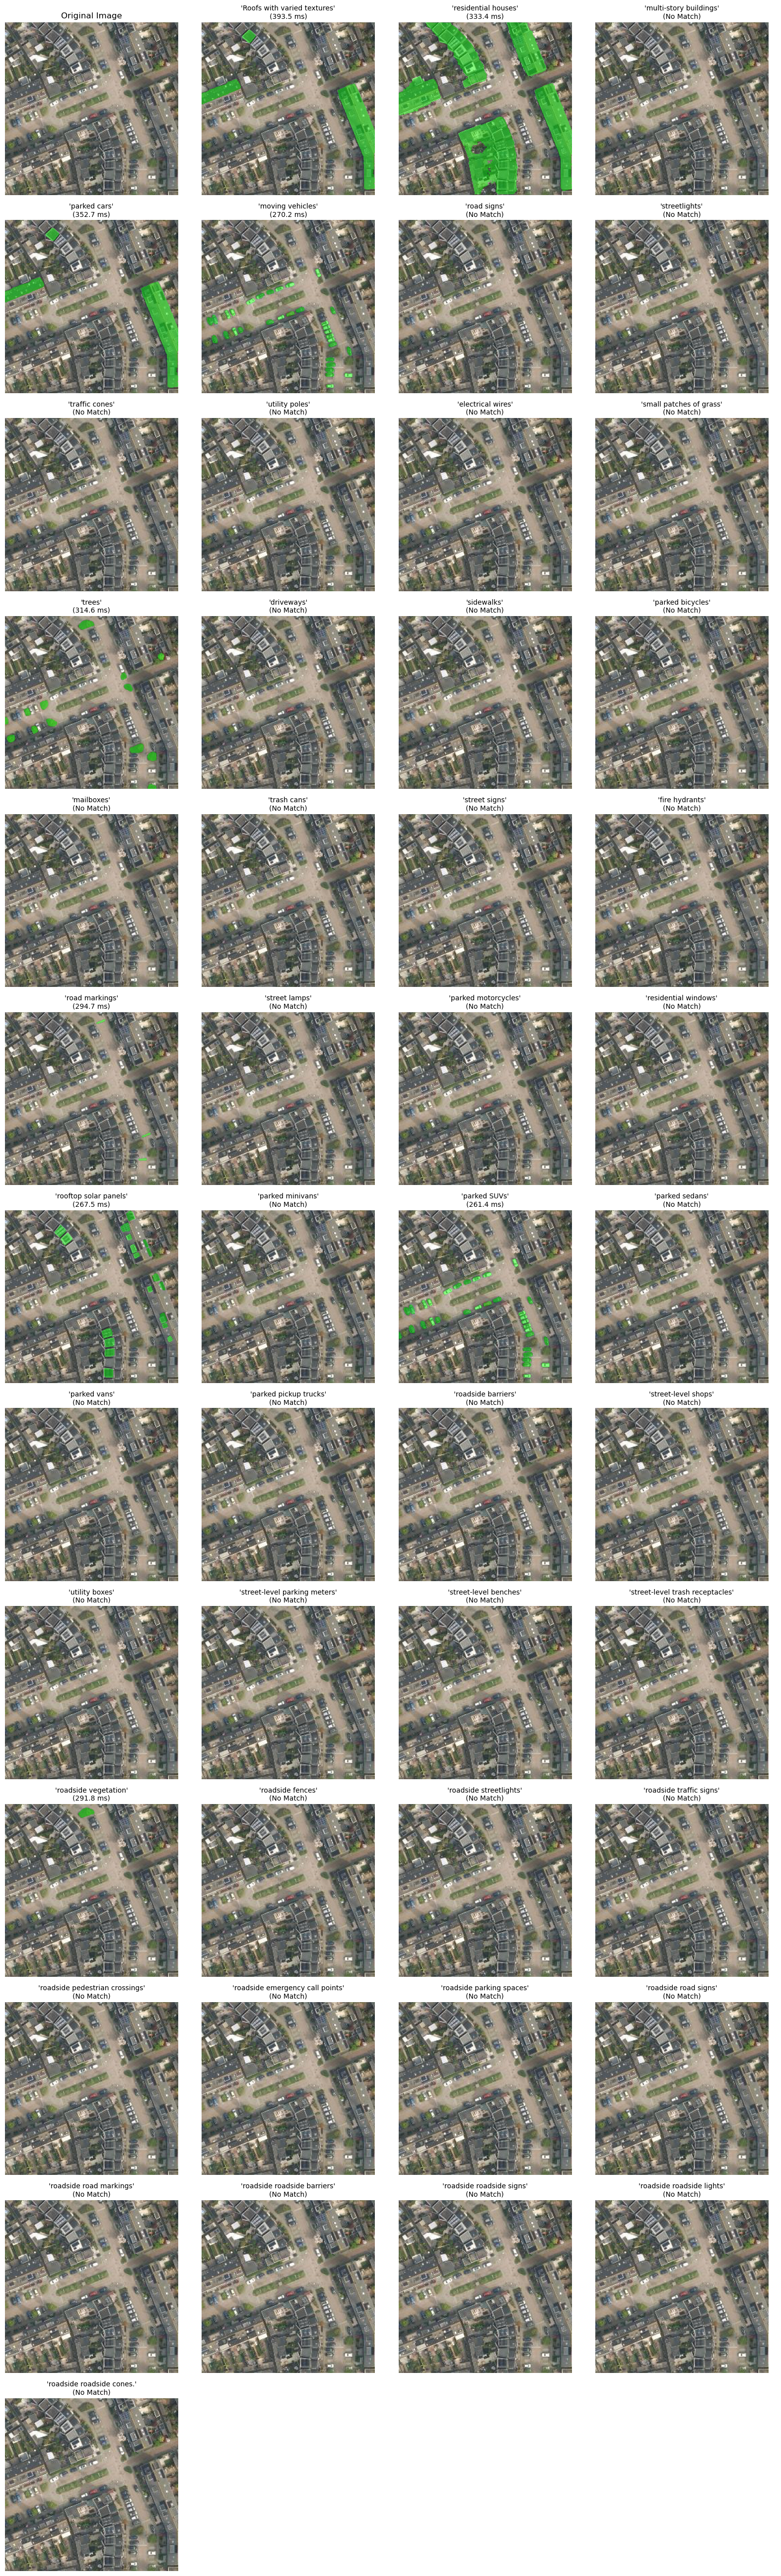

In [47]:
import io
import time
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from ollama import chat

# SAM 3 imports
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# --- 1. Global Setup (Load SAM 3 once) ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

print(f"Loading SAM 3 model on {DEVICE}...")
sam3_model = build_sam3_image_model().to(device=DEVICE)
sam3_processor = Sam3Processor(sam3_model)


# --- 2. Worker Function for Prompt Processing ---
def predict_single_prompt(processor, state, prompt: str):
    """Executes SAM 3 text prompt over precomputed image features."""
    t0 = time.perf_counter()

    with torch.cuda.amp.autocast(dtype=DTYPE):
        output = processor.set_text_prompt(state=state, prompt=prompt)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    latency = (time.perf_counter() - t0) * 1000  # in ms
    masks = output.get("masks", [])

    if len(masks) == 0:
        combined_mask = None
    else:
        masks_np = masks.detach().cpu().numpy() if isinstance(masks, torch.Tensor) else np.array(masks)
        masks_np = np.squeeze(masks_np)
        combined_mask = (masks_np > 0.5) if masks_np.ndim == 2 else np.any(masks_np > 0.5, axis=0)

    return prompt, combined_mask, latency


# --- 3. Main Pipeline Function ---
def process_row_and_segment(df: pd.DataFrame, row: int, max_workers: int = 4):
    img_bytes = df.at[row, "image_bytes"]
    image = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # Step A: Get keywords via Ollama
    print("Extracting keywords via Ollama (ministral-3:3b)...")
    ollama_start = time.perf_counter()
    response = chat(
        model="ministral-3:3b",
        messages=[{
            "role": "user",
            "content": "List all the things you see like labels in this image, like 'red buildings', 'car', 'tree'. Return just comma separated list and nothing else. Really try to focus on the small objects present. Try and not miss anything, and for example if a patch has rooftop panels, or red cars etc mention them as separate, try not to miss anything.",
            "images": [img_bytes],
        }],
    )
    ollama_time = (time.perf_counter() - ollama_start) * 1000

    keywords_raw = response.message.content.strip()
    keywords = [k.strip() for k in keywords_raw.split(",") if k.strip()]

    if "caption" in df.columns:
        print("Caption: ", df.at[row, "caption"])
    print(f"Keywords ({ollama_time:.1f} ms):", keywords)

    if not keywords:
        print("No keywords extracted.")
        return

    # Step B: Precompute SAM 3 Image Embeddings (Heavy step done ONLY ONCE)
    print("Computing SAM 3 image backbone embeddings...")
    embed_start = time.perf_counter()
    with torch.cuda.amp.autocast(dtype=DTYPE):
        inference_state = sam3_processor.set_image(image)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    embed_time = (time.perf_counter() - embed_start) * 1000

    # Step C: Run SAM 3 text prompts concurrently
    print(f"Running parallel segmentation for {len(keywords)} prompts...")
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(predict_single_prompt, sam3_processor, inference_state, key)
            for key in keywords
        ]
        results = [f.result() for f in futures]

    # Step D: Visualise all results in a single plot grid
    num_plots = len(results) + 1
    cols = min(4, num_plots)
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    # Plot Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Plot Each Keyword Overlay
    img_np = np.array(image)
    for i, (prompt, mask, latency) in enumerate(results, start=1):
        ax = axes[i]
        ax.imshow(image)

        if mask is not None:
            overlay = np.zeros((*img_np.shape[:2], 4), dtype=np.float32)
            overlay[mask] = [0.0, 1.0, 0.0, 0.45]  # Semi-transparent green
            ax.imshow(overlay)
            ax.set_title(f"'{prompt}'\n({latency:.1f} ms)", fontsize=10)
        else:
            ax.set_title(f"'{prompt}'\n(No Match)", fontsize=10)

        ax.axis("off")

    # Hide unused grid subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# --- 4. Example Usage ---
if __name__ == "__main__":
    # Assuming `df` is loaded from your parquet file:
    # df = pd.read_parquet("tiles_dataset.parquet")
    
    ROW_INDEX = 10
    process_row_and_segment(df, row=ROW_INDEX, max_workers=4)

Extracting keywords via Ollama (ministral-3:3b)...
Caption:  The satellite image shows a mixed landscape consisting of urban and rural areas. There is a river flowing through the center, bordered by patches of vegetation and agricultural fields. The urban areas are evident from clusters of buildings, mainly located on one side of the river. Several roads and pathways are connecting different parts of the landscape. The overall scene is a mix of natural and human-made structures.
Keywords (2123.9 ms): ['Roads', 'bridges', 'water bodies', 'scattered houses', 'rooftops', 'small clusters of buildings', 'agricultural fields', 'patches of greenery', 'trees', 'utility poles', 'power lines', 'small industrial structures', 'scattered vehicles', 'paved pathways', 'open fields', 'residential rooftops with possible solar panels', 'scattered patches of vegetation', 'small water reservoirs', 'and a few larger buildings near the center.']
Computing SAM 3 image backbone embeddings...
Running parallel 

C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\2675103702.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):
C:\Users\sus14836\AppData\Local\Temp\ipykernel_31256\2675103702.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):


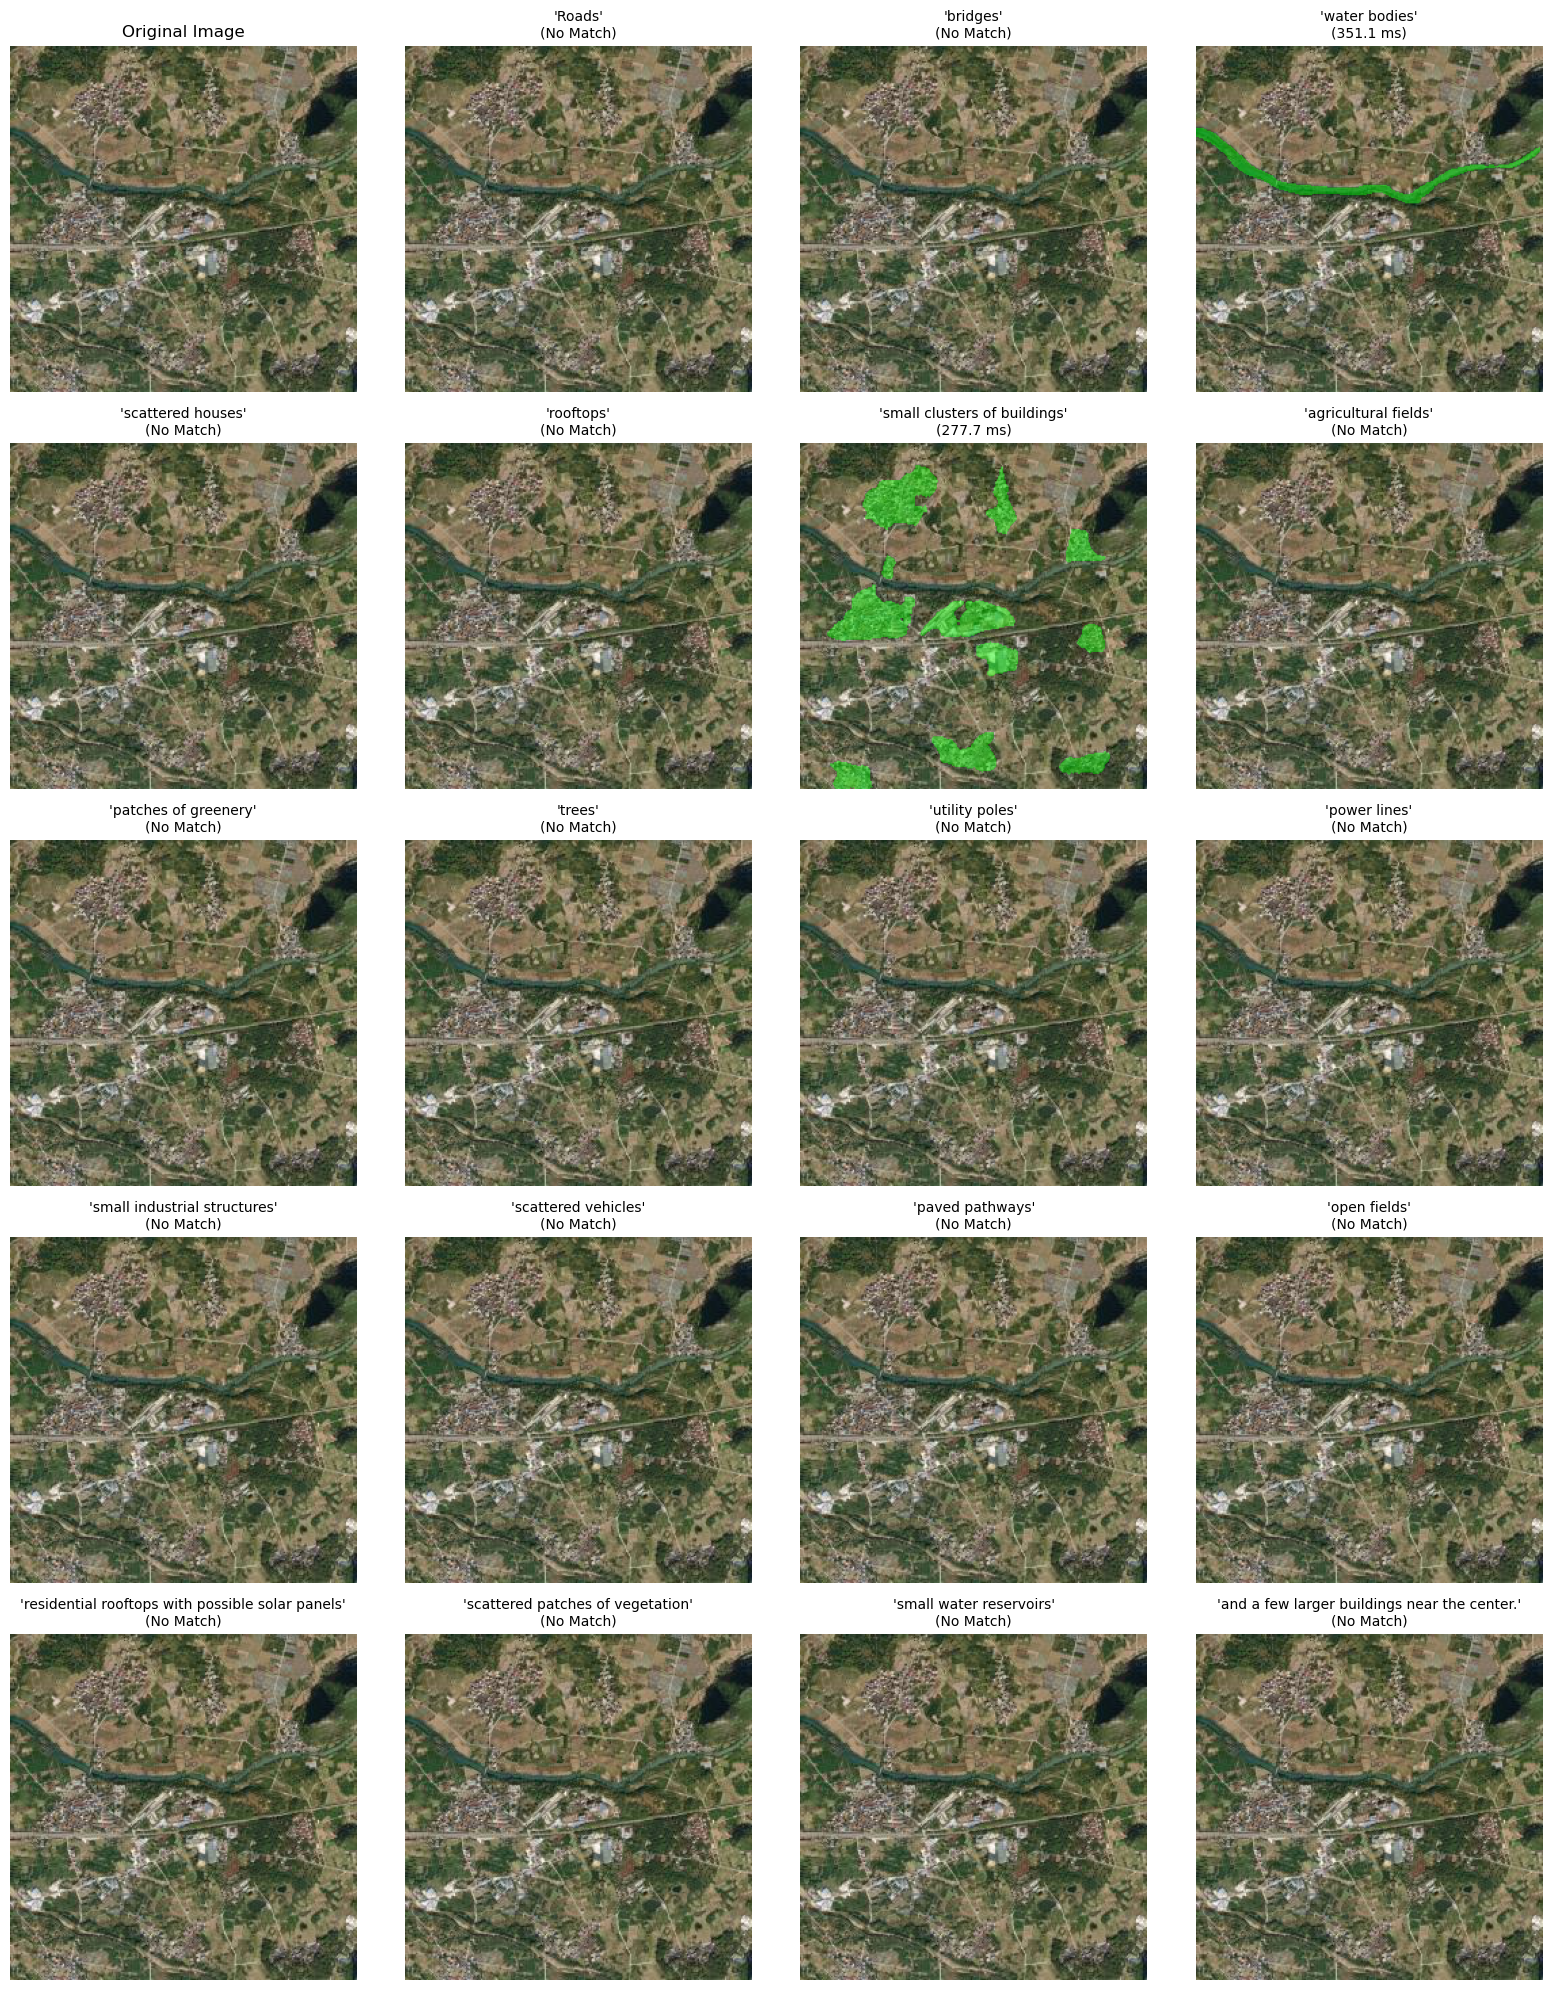

In [48]:
process_row_and_segment(df, 412336)